### Lab_1: Perform the QPSK modulation and demodulation using MATLAB/ Python. Display the signal and its constellation

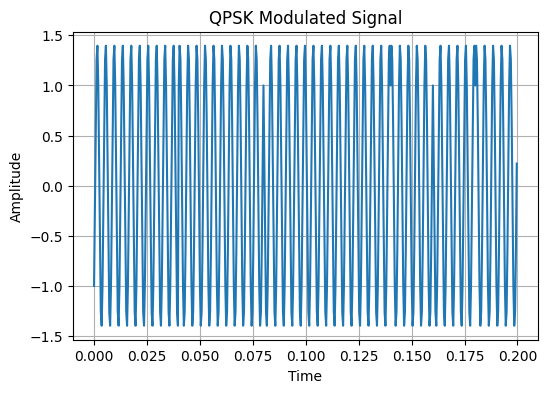

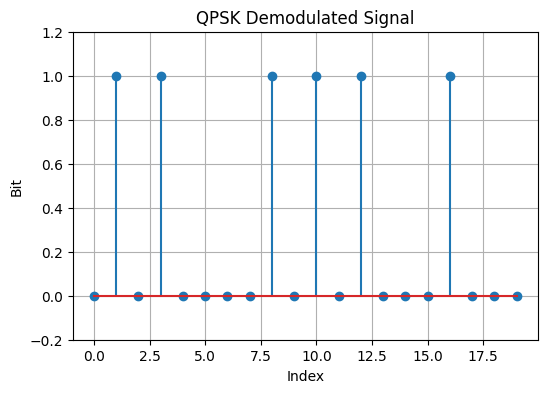

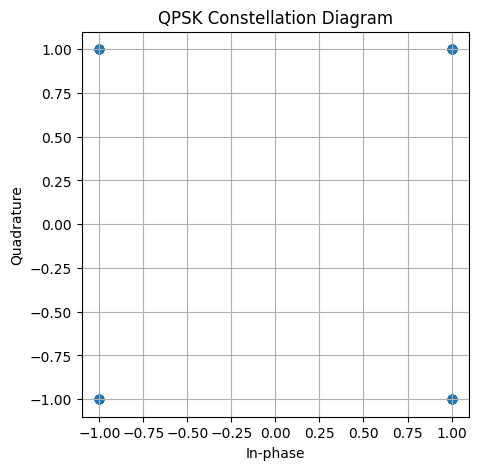

Original: [0 1 0 1 0 0 0 0 1 0 1 0 1 0 0 0 1 0 0 0]
Demodulated: [0 1 0 1 0 0 0 0 1 0 1 0 1 0 0 0 1 0 0 0]


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Generate random data
data = np.random.randint(0, 2, 100)

# Group into pairs
data_pairs = data.reshape(-1, 2)

# QPSK mapping
mapping = {
    (0,0): (1+1j),
    (0,1): (-1+1j),
    (1,1): (-1-1j),
    (1,0): (1-1j)
}

# Modulation (symbols)
symbols = np.array([mapping[tuple(b)] for b in data_pairs])

# ================= PERFECT QPSK SIGNAL =================
fc = 5
samples_per_symbol = 50

t_symbol = np.arange(samples_per_symbol) / samples_per_symbol

signal = []

for s in symbols:
    I = s.real
    Q = s.imag
    segment = I * np.cos(2 * np.pi * fc * t_symbol) + Q * np.sin(2 * np.pi * fc * t_symbol)
    signal.extend(segment)

signal = np.array(signal)
time_axis = np.linspace(0, 1, len(signal))

# ================= DEMODULATION =================
demod_bits = []
for s in symbols:
    if s.real > 0 and s.imag > 0:
        demod_bits.extend([0,0])
    elif s.real < 0 and s.imag > 0:
        demod_bits.extend([0,1])
    elif s.real < 0 and s.imag < 0:
        demod_bits.extend([1,1])
    else:
        demod_bits.extend([1,0])
demod_bits = np.array(demod_bits)

# ================= PLOTS (NO SUBPLOT) =================

# 1. QPSK Modulated Signal
plt.figure(figsize=(6,4))
plt.plot(time_axis[:500], signal[:500])
plt.title("QPSK Modulated Signal")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.grid()
plt.show()

# 2. QPSK Demodulated Signal
plt.figure(figsize=(6,4))
plt.stem(demod_bits[:20])
plt.title("QPSK Demodulated Signal")
plt.xlabel("Index")
plt.ylabel("Bit")
plt.ylim(-0.2, 1.2)
plt.grid()
plt.show()

# 3. QPSK Constellation Diagram
plt.figure(figsize=(5,5))
plt.scatter(symbols.real, symbols.imag)
plt.title("QPSK Constellation Diagram")
plt.xlabel("In-phase")
plt.ylabel("Quadrature")
plt.grid()
plt.show()

# ================= OUTPUT =================
print("Original:", data[:20])
print("Demodulated:", demod_bits[:20])

### Lab2: Generate 16-QAM modulation and obtain the QAM constellation using MATLAB/ Python.

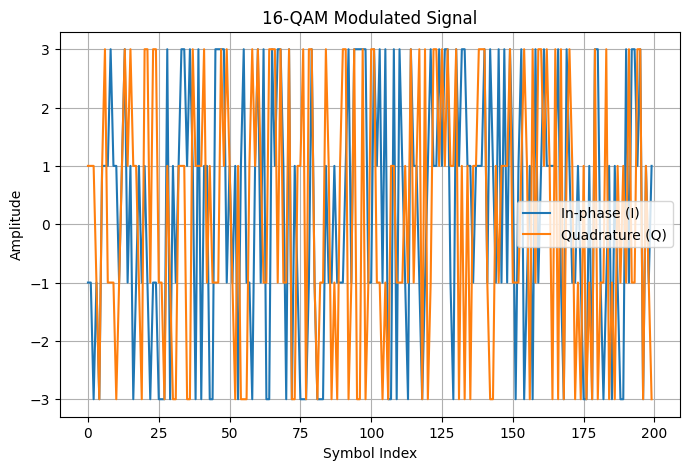

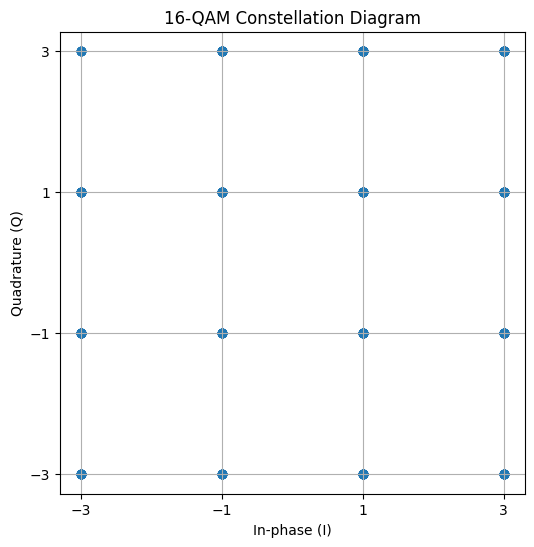

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Number of symbols
N = 200

# Generate random bits
bits = np.random.randint(0, 2, N*4)

# Group into 4 bits
bit_groups = bits.reshape((N, 4))

# Gray coding mapping
mapping = {
    (0,0): -3, # low
    (0,1): -1, # mid
    (1,1):  1, # mid
    (1,0):  3  # high
}

# Generate I and Q
I = np.array([mapping[tuple(b[:2])] for b in bit_groups])
Q = np.array([mapping[tuple(b[2:])] for b in bit_groups])

# QAM Signal
qam_signal = I + 1j*Q

# Time axis
t = np.arange(N)

# ----------- 1. Modulated Signal -------------
plt.figure(figsize=(8,5))
plt.plot(t, np.real(qam_signal), label='In-phase (I)')
plt.plot(t, np.imag(qam_signal), label='Quadrature (Q)')
plt.title("16-QAM Modulated Signal")
plt.xlabel("Symbol Index")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.show()

# ----------- 2. Constellation Diagram ----------
plt.figure(figsize=(6,6))
plt.scatter(np.real(qam_signal), np.imag(qam_signal))
plt.title("16-QAM Constellation Diagram")
plt.xlabel("In-phase (I)")
plt.ylabel("Quadrature (Q)")
plt.grid(True)
plt.xticks([-3, -1, 1, 3])
plt.yticks([-3, -1, 1, 3])
plt.axis('equal')
plt.show()

### Lab 3: Perform sampling and reconstruction of continuous signal using MATLAB/ Python.

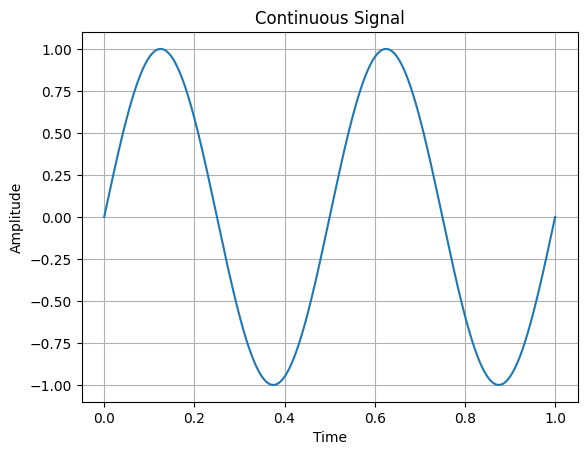

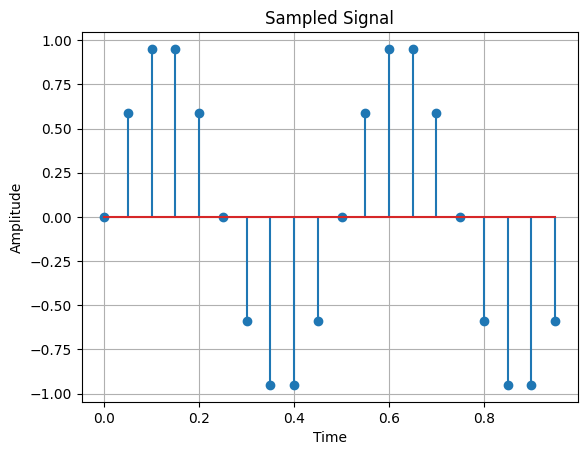

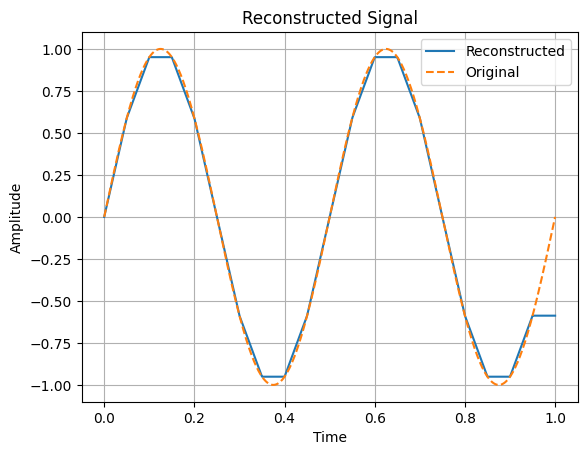

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Continuous signal parameters
f = 2
t = np.linspace(0, 1, 1000)

# Original signal
x = np.sin(2 * np.pi * f * t)

# Sampling
fs = 20
ts = np.arange(0, 1, 1/fs)
xs = np.sin(2 * np.pi * f * ts)

# Reconstruction
t_rec = np.linspace(0, 1, 1000)
x_rec = np.interp(t_rec, ts, xs)

# -------- 1. Continuous Signal --------
plt.figure()
plt.plot(t, x)
plt.title("Continuous Signal")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.grid()
plt.show()

# -------- 2. Sampled Signal --------
plt.figure()
plt.stem(ts, xs)
plt.title("Sampled Signal")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.grid()
plt.show()

# -------- 3. Reconstructed Signal --------
plt.figure()
plt.plot(t_rec, x_rec, label='Reconstructed')
plt.plot(t, x, '--', label='Original')
plt.title("Reconstructed Signal")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.legend()
plt.grid()
plt.show()

###  Lab 4: To generate the waveform of Quadrature Phase Shift Keying signal using MATLAB/ Python

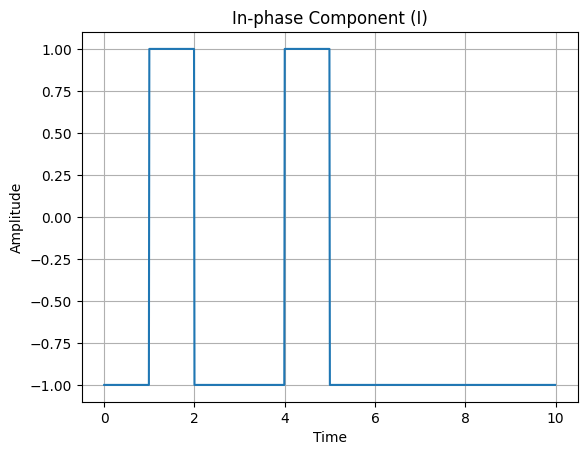

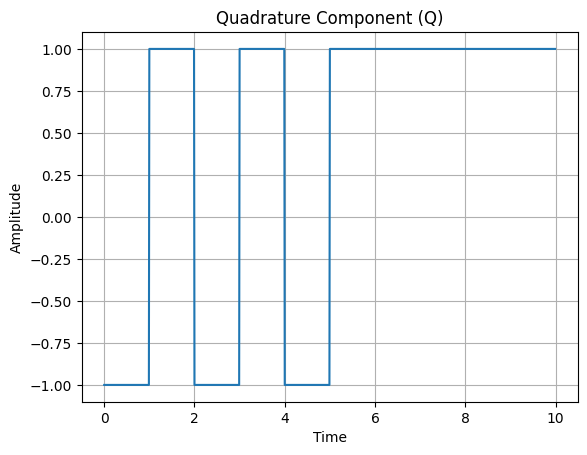

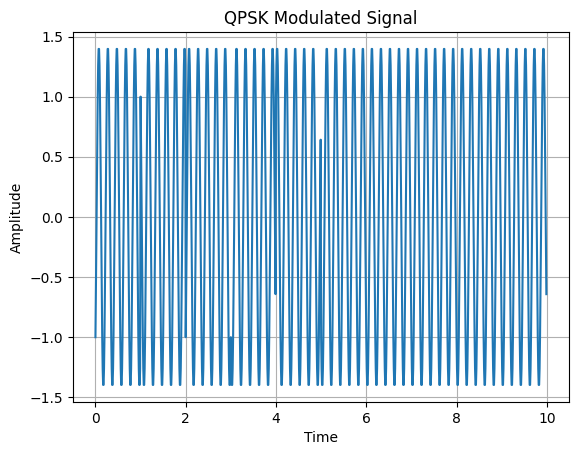

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
num_bits = 20
bit_rate = 1
fc = 5
samples_per_bit = 100

# Generate random bits
bits = np.random.randint(0, 2, num_bits)

# Group bits into pairs
bit_pairs = bits.reshape(-1, 2)

# Mapping (Gray coding)
mapping = {
    (0, 0): (1, 1),
    (0, 1): (-1, 1),
    (1, 1): (-1, -1),
    (1, 0): (1, -1)
}

I = []
Q = []

for pair in bit_pairs:
    i, q = mapping[tuple(pair)]
    I.extend([i] * samples_per_bit)
    Q.extend([q] * samples_per_bit)

I = np.array(I)
Q = np.array(Q)

# Time
t = np.arange(0, len(I)) / samples_per_bit

# Carrier
carrier_I = np.cos(2 * np.pi * fc * t)
carrier_Q = np.sin(2 * np.pi * fc * t)

# QPSK signal
qpsk_signal = I * carrier_I - Q * carrier_Q

# -------- 1. I component --------
plt.figure()
plt.plot(t, I)
plt.title("In-phase Component (I)")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.grid()
plt.show()

# -------- 2. Q component --------
plt.figure()
plt.plot(t, Q)
plt.title("Quadrature Component (Q)")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.grid()
plt.show()

# -------- 3. QPSK Signal --------
plt.figure()
plt.plot(t, qpsk_signal)
plt.title("QPSK Modulated Signal")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.grid()
plt.show()

### Lab 5: Perform the PAM modulation and demodulation using MATLAB/ Python

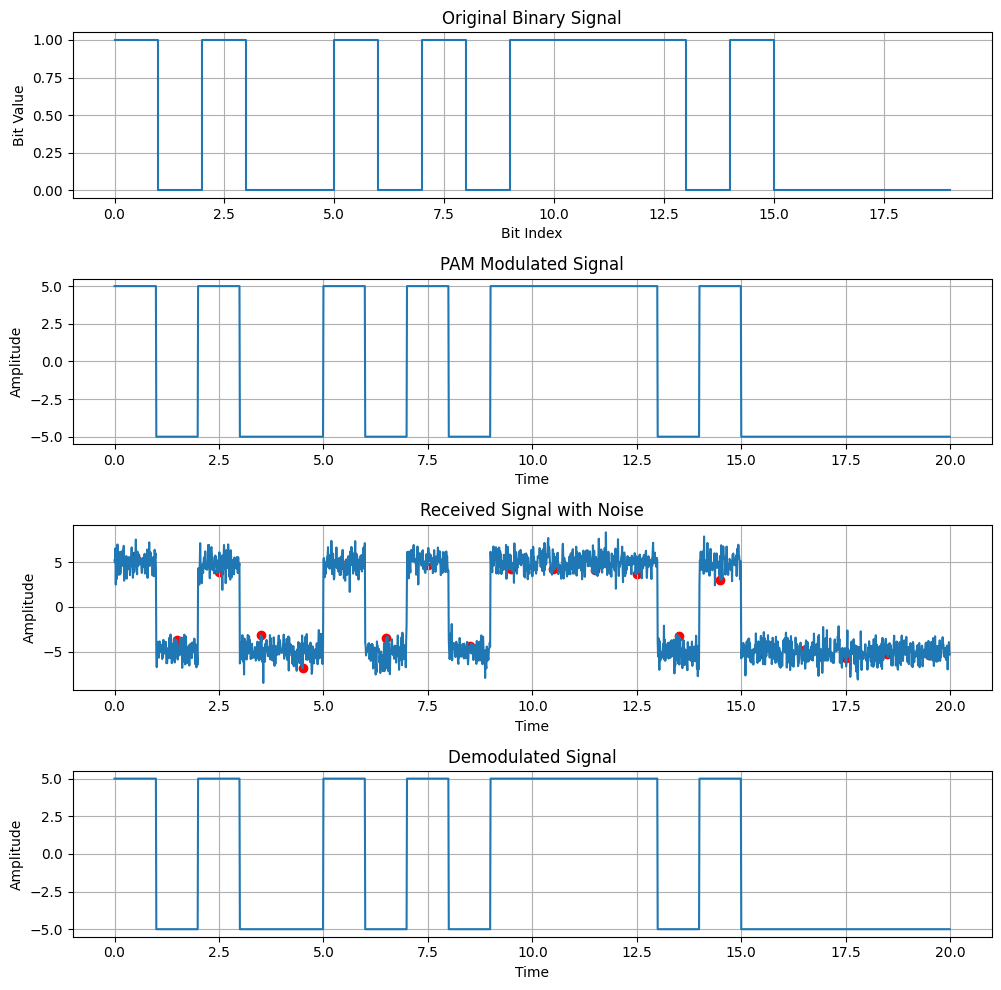

In [8]:
# lab 5

import numpy as np
import matplotlib.pyplot as plt

# Parameters
num_bits = 20
samples_per_bit = 100
amplitude = 5

# Generate random binary data
bits = np.random.randint(0, 2, num_bits)

# PAM Mapping: 0 -> -A, 1 -> +A
pam_symbols = np.where(bits == 1, amplitude, -amplitude)

# Upsample (modulated signal)
pam_signal = np.repeat(pam_symbols, samples_per_bit)

# Time axis
t = np.arange(len(pam_signal)) / samples_per_bit

# Add noise
noise = np.random.normal(0, 1, len(pam_signal))
received_signal = pam_signal + noise

# Demodulation
sample_points = np.arange(samples_per_bit//2, len(received_signal), samples_per_bit)
sampled_values = received_signal[sample_points]

# Decision rule
recovered_bits = (sampled_values > 0).astype(int)

# Demodulated waveform
demod_symbols = np.where(recovered_bits == 1, amplitude, -amplitude)
demod_signal = np.repeat(demod_symbols, samples_per_bit)

# Plotting
plt.figure(figsize=(10, 10))

# 1. Original Bits
plt.subplot(4,1,1)
plt.step(np.arange(len(bits)), bits, where='post')
plt.title("Original Binary Signal")
plt.xlabel("Bit Index")
plt.ylabel("Bit Value")
plt.grid()

# 2. PAM Modulated Signal
plt.subplot(4,1,2)
plt.plot(t, pam_signal)
plt.title("PAM Modulated Signal")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.grid()

# 3. Received Signal (with Noise)
plt.subplot(4,1,3)
plt.plot(t, received_signal)
plt.scatter(sample_points/samples_per_bit, sampled_values, color='red')
plt.title("Received Signal with Noise")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.grid()

# 4. Demodulated Signal
plt.subplot(4,1,4)
plt.plot(t, demod_signal)
plt.title("Demodulated Signal")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.grid()


plt.tight_layout()
plt.show()

### Lab6: Perform the DPCM modulation and demodulation using MATLAB/ Python.

In [ ]:
# lab 6

import numpy as np
import matplotlib.pyplot as plt

# Generate input signal
t = np.linspace(0, 1, 200)
x = np.sin(2 * np.pi * 5 * t)

# DPCM Modulation
predicted = np.zeros(len(x))
error = np.zeros(len(x))
quantized_error = np.zeros(len(x))

step_size = 0.2

for i in range(1, len(x)):
    predicted[i] = x[i-1]
    error[i] = x[i] - predicted[i]
    quantized_error[i] = step_size * np.round(error[i] / step_size)

# DPCM Demodulation
reconstructed = np.zeros(len(x))

for i in range(1, len(x)):
    reconstructed[i] = reconstructed[i-1] + quantized_error[i]


# Plotting
plt.figure(figsize=(10, 8))

# 1. Original Signal
plt.subplot(4,1,1)
plt.plot(t, x)
plt.title("Original Signal")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.grid()


# 2. Prediction Error
plt.subplot(4,1,2)
plt.plot(t, error)
plt.title("Prediction Error Signal")
plt.xlabel("Time")
plt.ylabel("Error")
plt.grid()


# 3. Quantized Error
plt.subplot(4,1,3)
plt.plot(t, quantized_error)
plt.title("Quantized Error Signal")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.grid()


# 4. Reconstructed Signal
plt.subplot(4,1,4)
plt.plot(t, reconstructed)
plt.title("Reconstructed Signal")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.grid()


plt.tight_layout()
plt.show()